In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv(r"D:\Thesis - November\Dataset\aligned_filtered_seqs_merged.csv")
filtered_df = pd.read_csv(r"D:\Thesis - November\Dataset\ANARCII\final_nanobodies_imgt_filtered.csv")

In [13]:
cdr1_start = '27'
cdr1_end = '38'

cdr2_start = '56'
cdr2_end = '65'

cdr3_start = '105'
cdr3_end = '117'

all_cols =filtered_df.columns.tolist()

cdr1_start_idx = all_cols.index(cdr1_start)
cdr1_end_idx = all_cols.index(cdr1_end)

cdr2_start_idx = all_cols.index(cdr2_start)
cdr2_end_idx = all_cols.index(cdr2_end)

cdr3_start_idx = all_cols.index(cdr3_start)
cdr3_end_idx = all_cols.index(cdr3_end)

cdr1_region = filtered_df.loc[:, [all_cols[0]] + all_cols[cdr1_start_idx:cdr1_end_idx+1]]
cdr2_region = filtered_df.loc[:, [all_cols[0]] + all_cols[cdr2_start_idx:cdr2_end_idx+1]]
cdr3_region = filtered_df.loc[:, [all_cols[0]] + all_cols[cdr3_start_idx:cdr3_end_idx+1]]

In [14]:
sequence_name = filtered_df[all_cols[0]]

cdr1_drop = cdr1_region.drop([all_cols[0]], axis=1)
cdr2_drop = cdr2_region.drop([all_cols[0]], axis=1)
cdr3_drop = cdr3_region.drop([all_cols[0]], axis=1)

cdr1_combined = cdr1_drop.astype(str).agg(''.join, axis=1)
cdr2_combined = cdr2_drop.astype(str).agg(''.join, axis=1)
cdr3_combined = cdr3_drop.astype(str).agg(''.join, axis=1)


cdrs_df = pd.DataFrame({
    all_cols[0]: sequence_name,
    'CDR1': cdr1_combined,
    'CDR2': cdr2_combined,
    'CDR3': cdr3_combined})

In [15]:
print(cdrs_df.head())

              Name          CDR1          CDR2                        CDR3
0  Nb_b4e8a5cd02e4  GRSF----STYA  ISWT-----DST  AADRWASS----------RRNVDYDY
1  Nb_7465735fff7e  GSIS----GDGD  IARG-----GST  AAHAVL--------------GYDHDY
2  Nb_bd4b72b8564c  GSIF----SGSF  ISDG-----AST  AAVLYP--------------PYPYDY
3  Nb_68c066c35d0b  GTIF----IEYF  IDRG-----GST  AARYWR--------------EYTHSY
4  Nb_a615e75371ee  GSIS----FVAD  ISYG-----SST  AVDEYDQN----------DGGYSYGY


In [16]:
cdrs_df.rename(columns={"CDR1": "CDR1 with gaps", "CDR2": "CDR2 with gaps", "CDR3": "CDR3 with gaps"}, inplace=True)
print(cdrs_df.head())

              Name CDR1 with gaps CDR2 with gaps              CDR3 with gaps
0  Nb_b4e8a5cd02e4   GRSF----STYA   ISWT-----DST  AADRWASS----------RRNVDYDY
1  Nb_7465735fff7e   GSIS----GDGD   IARG-----GST  AAHAVL--------------GYDHDY
2  Nb_bd4b72b8564c   GSIF----SGSF   ISDG-----AST  AAVLYP--------------PYPYDY
3  Nb_68c066c35d0b   GTIF----IEYF   IDRG-----GST  AARYWR--------------EYTHSY
4  Nb_a615e75371ee   GSIS----FVAD   ISYG-----SST  AVDEYDQN----------DGGYSYGY


In [17]:
new_df = df[df["Nanobody_id"].isin(filtered_df["Name"])]
new_df = new_df.rename(columns={"igghAaSequence": "Sequence", "cdrh3Sequence": "CDR3", "cdrh2Sequence": "CDR2", "cdrh1Sequence": "CDR1"})
new_df = new_df[["Nanobody_id", "Label", "Sequence", "CDR1", "CDR2", "CDR3"]]

In [18]:
print(new_df.columns)

Index(['Nanobody_id', 'Label', 'Sequence', 'CDR1', 'CDR2', 'CDR3'], dtype='object')


In [19]:
df_merged = new_df.merge(cdrs_df, how="left",left_on="Nanobody_id", right_on="Name")


In [20]:
print(len(df_merged))
print(df_merged.head())

148573
       Nanobody_id  Label                                           Sequence  \
0  Nb_b4e8a5cd02e4      1  QVQLQESGGGSVQAGGSLKLSCAASGRSFSTYAMGWFRQAPGQDRE...   
1  Nb_7465735fff7e      1  QVQLQESGGGLVQAGGSLRLSCAASGSISGDGDMGWYRQAPGKERE...   
2  Nb_bd4b72b8564c      1  QVQLQESGGGLVQAGGSLRLSCAASGSIFSGSFMGWYRQAPGKERE...   
3  Nb_68c066c35d0b      1  QVQLQESGGGLVQAGGSLRLSCAASGTIFIEYFMGWYRQAPGKERE...   
4  Nb_a615e75371ee      1  QVQLQESGGGLVQAGGSLRLSCAASGSISFVADMGWYRQAPGKERE...   

       CDR1     CDR2              CDR3             Name CDR1 with gaps  \
0  GRSFSTYA  ISWTDST  AADRWASSRRNVDYDY  Nb_b4e8a5cd02e4   GRSF----STYA   
1  GSISGDGD  IARGGST      AAHAVLGYDHDY  Nb_7465735fff7e   GSIS----GDGD   
2  GSIFSGSF  ISDGAST      AAVLYPPYPYDY  Nb_bd4b72b8564c   GSIF----SGSF   
3  GTIFIEYF  IDRGGST      AARYWREYTHSY  Nb_68c066c35d0b   GTIF----IEYF   
4  GSISFVAD  ISYGSST  AVDEYDQNDGGYSYGY  Nb_a615e75371ee   GSIS----FVAD   

  CDR2 with gaps              CDR3 with gaps  
0   ISWT-----DST  AA

In [21]:
df_merged = df_merged.drop(columns=["Name"])

df_merged.to_csv(r"D:\Thesis - November\Dataset\new_filtered_seqs_merged.csv", index=False)

Add full aligned sequence from ANARCII

In [23]:
full_df = pd.read_csv(r"D:\Thesis - November\Dataset\ANARCII\final_nanobodies_imgt_filtered.csv")
og_df = pd.read_csv(r"D:\Thesis - November\Dataset\new_filtered_seqs_merged.csv")
seqs_start = '1'
seqs_end = '128'

all_cols = full_df.columns.tolist()
start_idx = all_cols.index(seqs_start)
end_idx = all_cols.index(seqs_end)

seq = full_df.loc[:, all_cols[start_idx:end_idx+1]]
sequence_name = full_df[all_cols[0]]

seq_combined = seq.astype(str).agg(''.join, axis=1)
combined_seq_df = pd.DataFrame({
    'Nanobody_id': sequence_name,
    'Aligned Sequence': seq_combined
})

add_df = og_df.merge(combined_seq_df, on="Nanobody_id", how="left")
add_df.to_csv(r"D:\Thesis - November\Dataset\new_filtered_seqs_merged.csv", index=False)

In [24]:
print(len(add_df))

148573


Plots
1. Label distribution
2. CDR3 length distribution
3. CDR2 and CDR1 length distribution

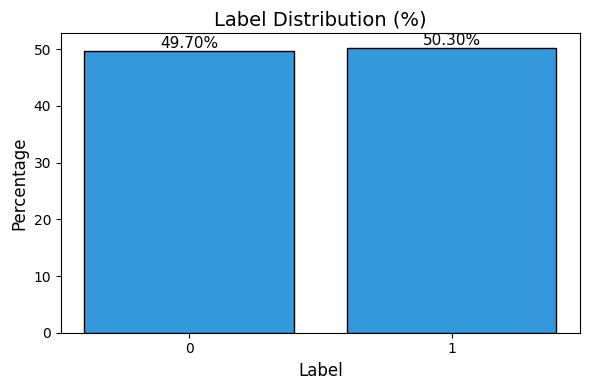

In [5]:
main_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\new_filtered_aligned_seqs_merged.csv")
label_counts = main_df['Label'].value_counts().sort_index()
label_percent = (label_counts / label_counts.sum()) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(label_percent.index.astype(str), label_percent.values, 
               color='#3498db', edgecolor='black')

plt.title("Label Distribution (%)", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Percentage", fontsize=12)

for i, v in enumerate(label_percent.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\label_distribution.png", dpi=300)
plt.show()

141015


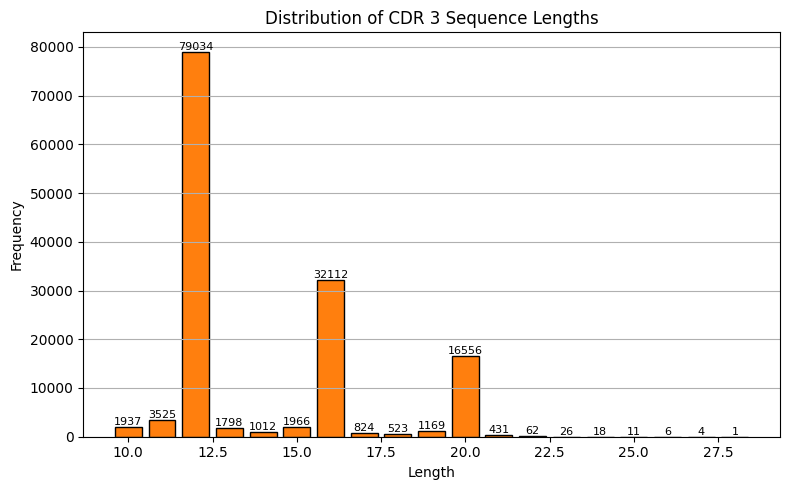

In [6]:

main_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\new_filtered_aligned_seqs_merged.csv")
print(len(main_df))
length_counts = main_df['CDR3'].astype(str).str.len().value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(length_counts.index, length_counts.values, color='#ff7f0e', edgecolor='black')
for x, y in zip(length_counts.index, length_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)
plt.title("Distribution of CDR 3 Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\CDR3_length_distribution.png", dpi=300)
plt.show()

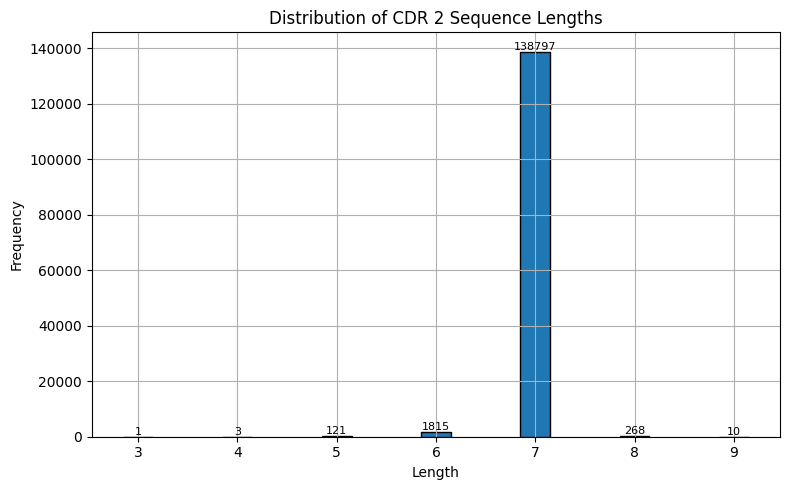

In [7]:
main_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\new_filtered_aligned_seqs_merged.csv")
length_counts = main_df['CDR2'].astype(str).str.len().value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(length_counts.index, length_counts.values, color='#1f77b4', edgecolor='black', width=0.3)
for x, y in zip(length_counts.index, length_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)
plt.title("Distribution of CDR 2 Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\CDR2_length_distribution.png", dpi=300)
plt.show()

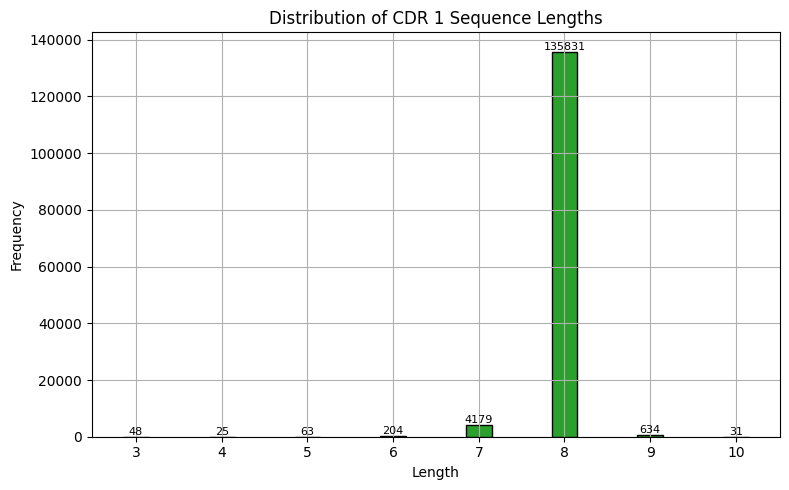

In [8]:
main_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\new_filtered_aligned_seqs_merged.csv")
length_counts = main_df['CDR1'].astype(str).str.len().value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(length_counts.index, length_counts.values, color='#2ca02c', edgecolor='black', width=0.3)
for x, y in zip(length_counts.index, length_counts.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)
plt.title("Distribution of CDR 1 Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"D:\Thesis EGFR dataset\Figures\CDR1_length_distribution.png", dpi=300)
plt.show()